# Student Performance Prediction Using Supervised Machine Learning

### Week 6 Capstone Project

**Problem Type:** Regression  
**Dataset:** UCI Student Performance Dataset  
**Primary Dataset:** Mathematics (`student-mat.csv`)  
**Target Variable:** `G3` — Final Mathematics Grade  
**Target Range:** 0–20  
**Final Model:** Random Forest Regressor

---

## Project Objective

The objective of this project is to develop a supervised machine learning regression system that predicts a student's final mathematics grade using academic, demographic, social, and behavioral attributes.

The notebook presents the complete analytical workflow from data loading and validation through exploratory data analysis, preprocessing, model comparison, evaluation, hyperparameter tuning, feature importance, and error analysis.


## Executive Summary

The project evaluates multiple supervised regression algorithms for predicting the final mathematics grade (`G3`).

Four baseline models were compared:

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor

The **Random Forest Regressor** achieved the strongest baseline performance with an **RMSE of 2.0150** and an **R² of 0.8020** on the held-out test set.

The analysis also compares a full-information scenario with a pre-grade scenario where `G1` and `G2` are excluded. This demonstrates the substantial predictive contribution of previous academic performance.


# 1. Environment and Libraries

The project uses Python with Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

A fixed random seed of `42` is used wherever applicable to improve reproducibility.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('Python version :', sys.version.split()[0])
print('Pandas version :', pd.__version__)
print('NumPy version  :', np.__version__)


Python version : 3.14.7
Pandas version : 3.0.6
NumPy version  : 2.5.3


# 2. Project Configuration

The mathematics dataset is used as the primary modeling dataset. The Portuguese dataset is retained in the project as a reference dataset but is not used for the final model.


In [2]:
RANDOM_STATE = 42
DATA_PATH = Path('data/student-mat-cleaned.csv')

print('Random state:', RANDOM_STATE)
print('Dataset path:', DATA_PATH)
print('Dataset exists:', DATA_PATH.exists())


Random state: 42
Dataset path: data\student-mat-cleaned.csv
Dataset exists: True


# 3. Data Loading

The cleaned mathematics dataset contains 395 student records and 33 variables, including the target variable `G3`.

In [3]:
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded successfully.')
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')

display(df.head())

Dataset loaded successfully.
Rows    : 395
Columns : 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


# 4. Data Quality Assessment

The dataset was checked for dimensions, missing values, duplicate records, data types, and basic statistical characteristics.

In [4]:
quality_summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicate Rows'],
    'Value': [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum())
    ]
})

display(quality_summary)

print('Data type distribution:')
display(df.dtypes.value_counts())

,Metric,Value
0,Rows,395
1,Columns,33
2,Missing Values,0
3,Duplicate Rows,0


Data type distribution:


str      17
int64    16
Name: count, dtype: int64

### Data Quality Findings

The primary dataset contains **395 observations and 33 variables**. The completed validation identified **0 missing values** and **0 duplicate rows**.

Logical range validation did not identify invalid values. Extreme absence values were investigated and retained because they may represent legitimate student records rather than data-entry errors.

# 5. Target Variable Analysis

The target variable `G3` represents the student's final mathematics grade on a scale from 0 to 20.

In [5]:
g3_summary = df['G3'].describe().to_frame('G3')
display(g3_summary)

print(f"Mean   : {df['G3'].mean():.4f}")
print(f"Median : {df['G3'].median():.4f}")
print(f"Minimum: {df['G3'].min():.0f}")
print(f"Maximum: {df['G3'].max():.0f}")
print(f"Skew   : {df['G3'].skew():.4f}")

,G3
count,395.0000
mean,10.4152
std,4.5814
min,0.0000
25%,8.0000
50%,11.0000
75%,14.0000
max,20.0000


Mean   : 10.4152
Median : 11.0000
Minimum: 0
Maximum: 20
Skew   : -0.7327


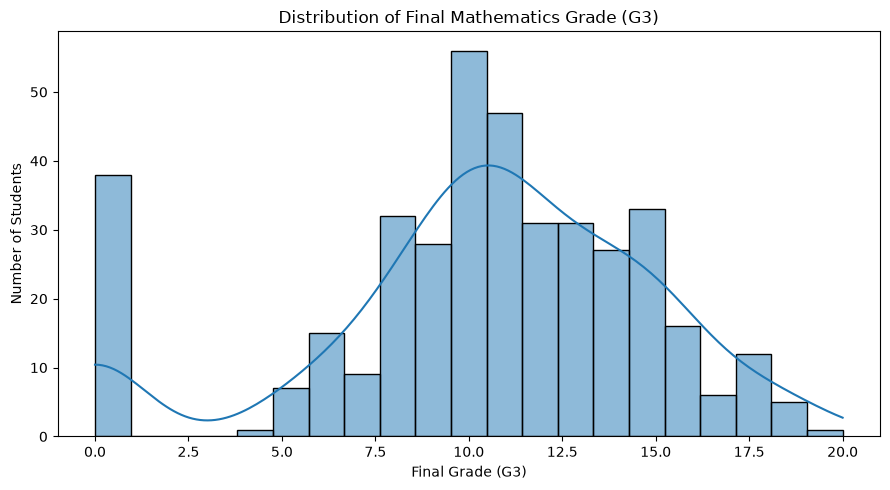

In [6]:
plt.figure(figsize=(9, 5))
sns.histplot(df['G3'], bins=21, kde=True)
plt.title('Distribution of Final Mathematics Grade (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

### Target Interpretation

The final mathematics grade has a mean of approximately **10.42** and a median of **11**. The observed range is **0–20**. The distribution is negatively skewed, indicating relatively more observations toward the middle and upper portion of the grade range.

# 6. Exploratory Data Analysis

EDA is performed to understand relationships between student characteristics and final academic performance.

## 6.1 Previous Academic Grades

,G1,G2,G3
G1,1.0000,0.8521,0.8015
G2,0.8521,1.0000,0.9049
G3,0.8015,0.9049,1.0000


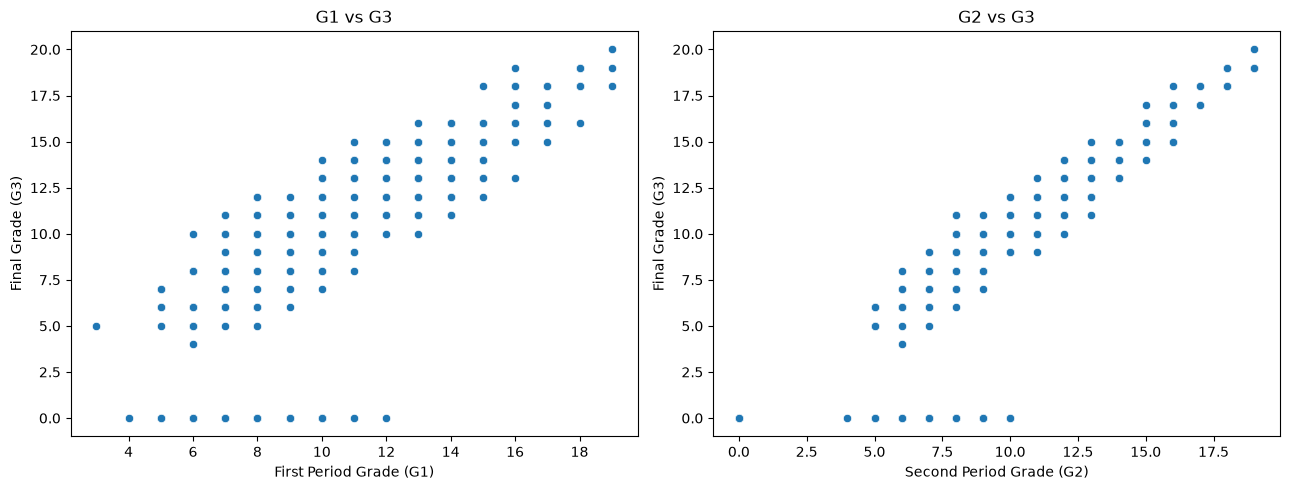

In [7]:
grade_corr = df[['G1', 'G2', 'G3']].corr()
display(grade_corr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='G1', y='G3', ax=axes[0])
axes[0].set_title('G1 vs G3')
axes[0].set_xlabel('First Period Grade (G1)')
axes[0].set_ylabel('Final Grade (G3)')

sns.scatterplot(data=df, x='G2', y='G3', ax=axes[1])
axes[1].set_title('G2 vs G3')
axes[1].set_xlabel('Second Period Grade (G2)')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()

### Interpretation

`G2` has the strongest observed numerical relationship with `G3`, followed by `G1`. This is expected because both variables represent previous academic performance.

## 6.2 Previous Failures

,failures,count,mean,median,std
0,0,312,11.2532,11.0000,4.1696
1,1,50,8.1200,9.0000,4.7106
2,2,17,6.2353,8.0000,4.8416
3,3,16,5.6875,7.0000,4.1908


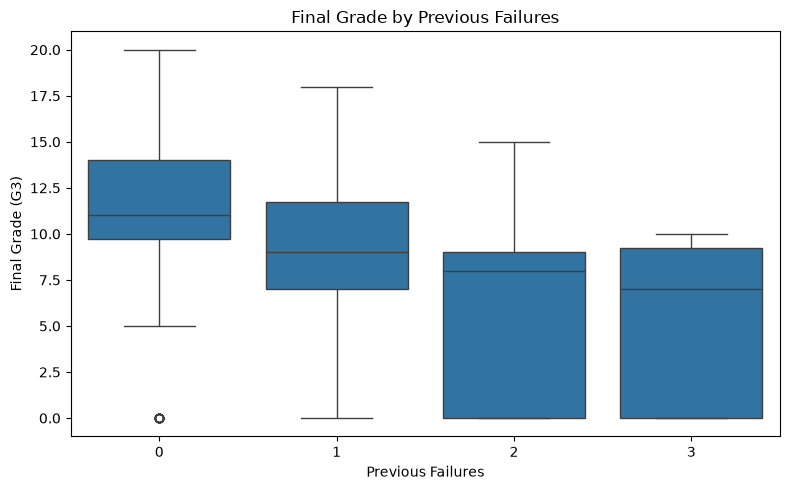

In [8]:
failure_summary = (
    df.groupby('failures')['G3']
      .agg(['count', 'mean', 'median', 'std'])
      .reset_index()
)

display(failure_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='failures', y='G3')
plt.title('Final Grade by Previous Failures')
plt.xlabel('Previous Failures')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

### Interpretation

Students with more previous failures tend to have lower average final grades. The observed mean decreases substantially as the number of previous failures increases.

## 6.3 Study Time

,studytime,count,mean,median
0,1,105,10.0476,10.0000
1,2,198,10.1717,11.0000
2,3,65,11.4000,12.0000
3,4,27,11.2593,12.0000


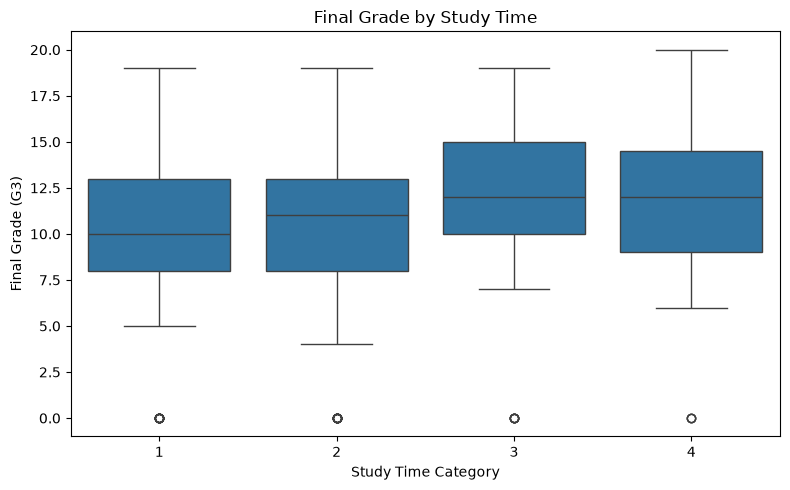

In [9]:
study_summary = (
    df.groupby('studytime')['G3']
      .agg(['count', 'mean', 'median'])
      .reset_index()
)

display(study_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='studytime', y='G3')
plt.title('Final Grade by Study Time')
plt.xlabel('Study Time Category')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

## 6.4 Absences

Pearson correlation between absences and G3: 0.0342


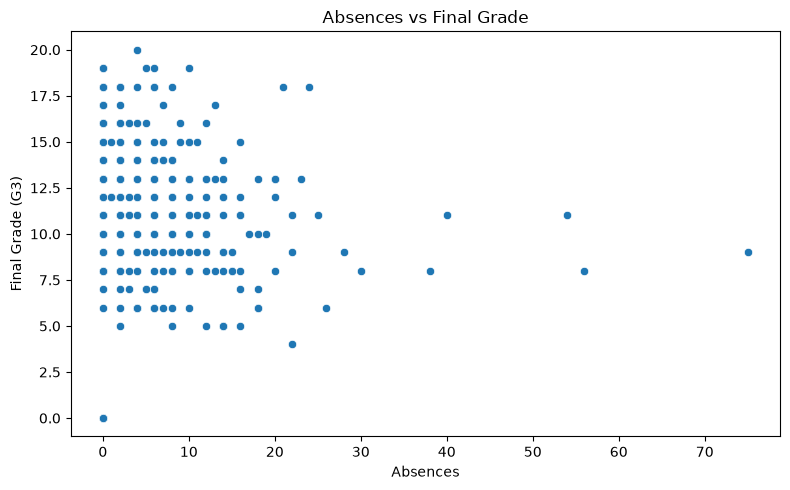

In [10]:
absence_corr = df[['absences', 'G3']].corr().iloc[0, 1]
print(f'Pearson correlation between absences and G3: {absence_corr:.4f}')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='absences', y='G3')
plt.title('Absences vs Final Grade')
plt.xlabel('Absences')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

### Interpretation

The Pearson correlation between absences and `G3` is approximately **0.0342**, indicating a very weak linear relationship. Nevertheless, absences can still provide predictive information to nonlinear models.

# 7. Correlation Analysis

,Correlation with G3
G3,1.0000
G2,0.9049
G1,0.8015
Medu,0.2171
Fedu,0.1525
studytime,0.0978
famrel,0.0514
absences,0.0342
freetime,0.0113
Walc,-0.0519


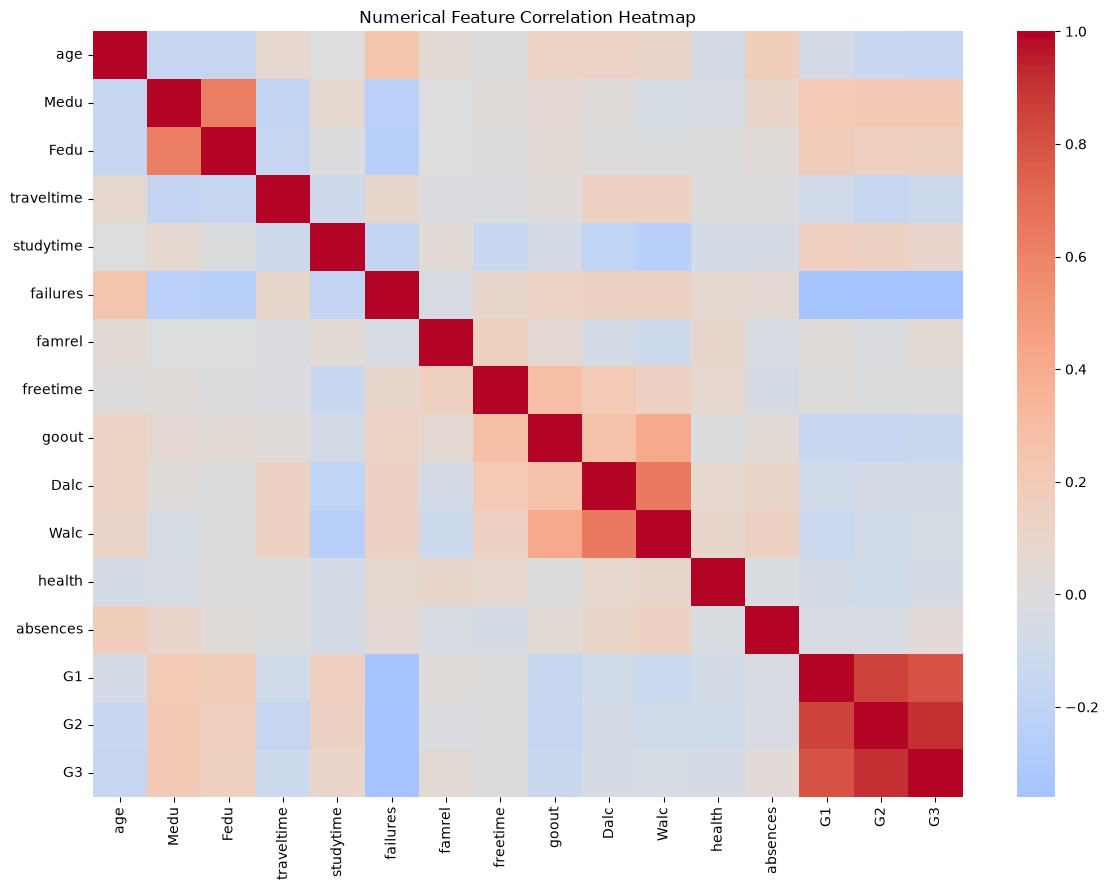

In [11]:
numeric_df = df.select_dtypes(include=np.number)
correlations = numeric_df.corr()['G3'].sort_values(ascending=False)

display(correlations.to_frame('Correlation with G3'))

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Important Correlation Findings

| Feature | Correlation with G3 |
|---|---:|
| G2 | 0.9049 |
| G1 | 0.8015 |
| failures | -0.3604 |
| Medu | 0.2171 |
| age | -0.1616 |
| Fedu | 0.1525 |

**Note:** Correlation describes association, not causation.

# 8. Feature Engineering and Preprocessing

The modeling pipeline separates numerical and categorical variables.

### Numerical preprocessing
- Median imputation
- Standard scaling

### Categorical preprocessing
- Most-frequent imputation
- One-hot encoding
- Unknown categories ignored

The preprocessing transformer is fitted only on the training partition to prevent information leakage.

In [12]:
X = df.drop(columns=['G3'])
y = df['G3']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Numerical features :', len(numerical_features))
print('Categorical features:', len(categorical_features))

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

Numerical features : 15
Categorical features: 17


# 9. Train-Test Split

An 80/20 hold-out split is used with `random_state=42`.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    'Partition': ['Training', 'Testing'],
    'Samples': [len(X_train), len(X_test)],
    'Percentage': [len(X_train)/len(df)*100, len(X_test)/len(df)*100]
})

display(split_summary)

,Partition,Samples,Percentage
0,Training,316,80.0000
1,Testing,79,20.0000


# 10. Baseline Model Development

Four regression algorithms are compared using the same preprocessing pipeline.

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

baseline_results = []

for name, estimator in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    baseline_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, predictions),
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2_score(y_test, predictions)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values('RMSE')
display(baseline_results_df)

,Model,MAE,MSE,RMSE,R²
3,Random Forest,1.2005,4.0601,2.0150,0.8020
1,Ridge Regression,1.6391,5.6242,2.3715,0.7257
0,Linear Regression,1.6467,5.6566,2.3784,0.7241
2,Decision Tree,1.3165,6.6076,2.5705,0.6778


# 11. Verified Model Comparison

The completed project produced the following test-set results for the Full Information scenario.

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 1.6467 | 5.6566 | 2.3784 | 0.7241 |
| Ridge Regression | 1.6391 | 5.6242 | 2.3715 | 0.7257 |
| Decision Tree | 1.3165 | 6.6076 | 2.5705 | 0.6778 |
| **Random Forest** | **1.2005** | **4.0601** | **2.0150** | **0.8020** |

Random Forest achieved the strongest baseline performance.

# 12. Previous-Grade Ablation Analysis

To understand the contribution of previous academic performance, a second modeling scenario was evaluated after removing `G1` and `G2`.

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 3.3953 | 17.6037 | 4.1957 | 0.1415 |
| Ridge Regression | 3.3929 | 17.5846 | 4.1934 | 0.1424 |
| Decision Tree | 3.6329 | 23.4051 | 4.8379 | -0.1414 |
| **Random Forest** | **2.9938** | **14.0686** | **3.7508** | **0.3139** |

Removing `G1` and `G2` reduced Random Forest R² from approximately **0.80 to 0.31**, demonstrating the strong predictive contribution of previous academic grades.

# 13. Hyperparameter Tuning

Random Forest was tuned using 5-fold cross-validation with negative RMSE as the optimization metric.

### Best Full Information Configuration

```text
n_estimators     = 400
max_depth        = None
max_features     = 1.0
min_samples_leaf = 2
min_samples_split= 2
```

### Tuned Performance

- MAE: 1.2123
- MSE: 4.0787
- RMSE: 2.0196
- R²: 0.8011

The tuned model was slightly worse than the baseline Random Forest. Therefore, the baseline configuration was retained as the final model.

# 14. Final Model

The final selected model is a **Random Forest Regressor** using the full information feature set.

Configuration:

```text
n_estimators = 200
random_state = 42
n_jobs = -1
```


In [15]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)
final_predictions = final_model.predict(X_test)

final_mse = mean_squared_error(y_test, final_predictions)
final_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [
        mean_absolute_error(y_test, final_predictions),
        final_mse,
        np.sqrt(final_mse),
        r2_score(y_test, final_predictions)
    ]
})

display(final_metrics)

,Metric,Value
0,MAE,1.2005
1,MSE,4.0601
2,RMSE,2.0150
3,R²,0.8020


## Verified Final Performance

| Metric | Result |
|---|---:|
| **MAE** | **1.2005** |
| **MSE** | **4.0601** |
| **RMSE** | **2.0150** |
| **R²** | **0.8020** |

An RMSE of approximately 2.02 means the typical prediction error is on the order of a few grade points. The R² value of approximately 0.80 indicates that the model explains a substantial proportion of the variation in the held-out target values.

# 15. Actual vs Predicted Performance

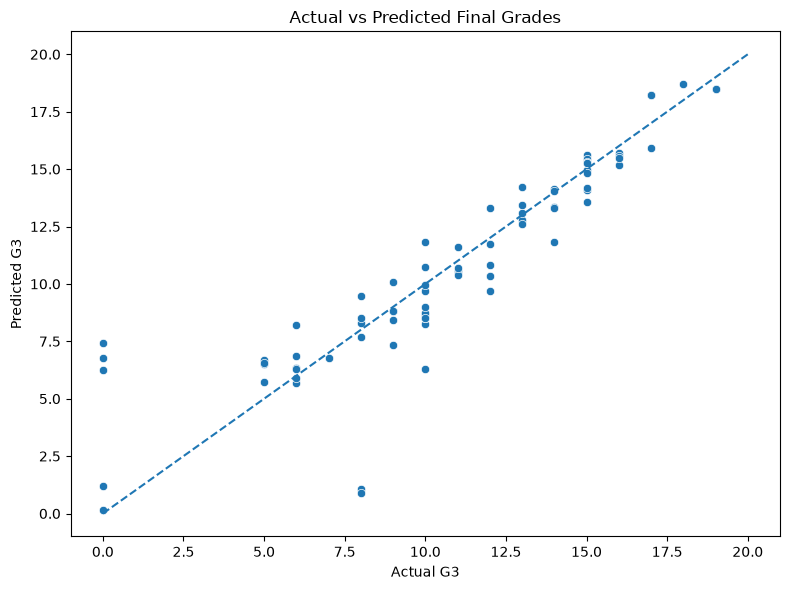

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=final_predictions)
plt.plot([0, 20], [0, 20], linestyle='--')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Final Grades')
plt.tight_layout()
plt.show()

# 16. Feature Importance

Random Forest feature importance is used to identify which transformed predictors contribute most strongly to the model's predictions.

,Feature,Importance
14,num__G2,0.7872
12,num__absences,0.1143
36,cat__reason_home,0.0190
0,num__age,0.0091
13,num__G1,0.0055
6,num__famrel,0.0050
11,num__health,0.0041
40,cat__guardian_mother,0.0037
8,num__goout,0.0036
4,num__studytime,0.0032


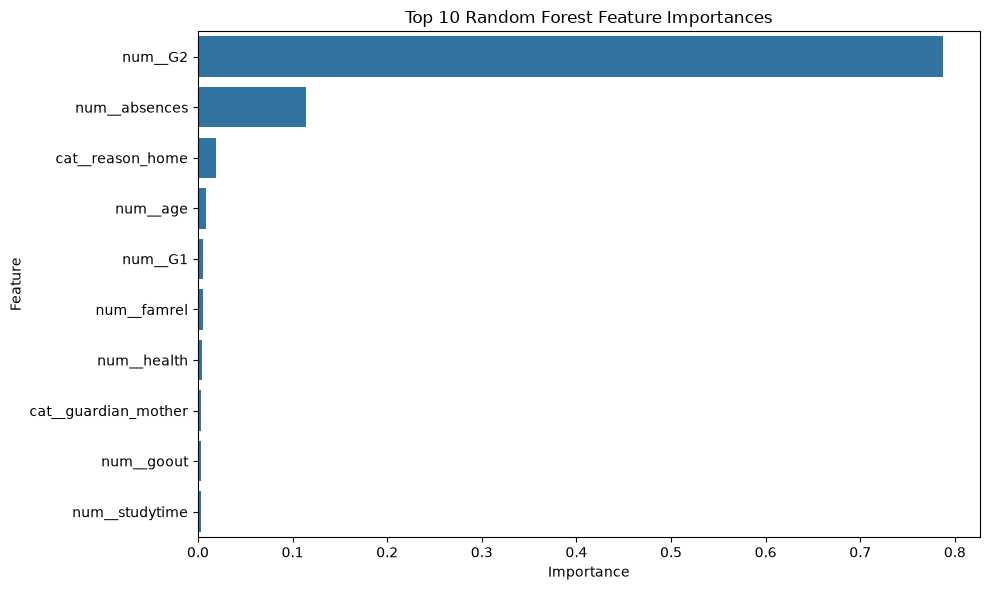

In [17]:
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
feature_importances = final_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Verified Feature Importance

| Feature | Importance |
|---|---:|
| `G2` | 0.7872 |
| `absences` | 0.1143 |
| `reason_home` | 0.0190 |
| `age` | 0.0091 |
| `G1` | 0.0055 |

`G2` is overwhelmingly the strongest predictive feature, followed by absences.

**Important:** Feature importance represents predictive contribution and does not establish causation.

# 17. Prediction Error Analysis

In [18]:
residuals = y_test.values - final_predictions
absolute_errors = np.abs(residuals)

error_analysis = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_predictions,
    'Error': residuals,
    'Absolute Error': absolute_errors
})

display(error_analysis.sort_values('Absolute Error', ascending=False).head(10))

,Actual,Predicted,Error,Absolute Error
8,0,7.4100,-7.4100,7.4100
34,8,0.9000,7.1000,7.1000
16,8,1.0900,6.9100,6.9100
19,0,6.7550,-6.7550,6.7550
24,0,6.2400,-6.2400,6.2400
45,10,6.3000,3.7000,3.7000
27,12,9.6800,2.3200,2.3200
70,6,8.2200,-2.2200,2.2200
38,14,11.8050,2.1950,2.1950
13,10,11.8450,-1.8450,1.8450


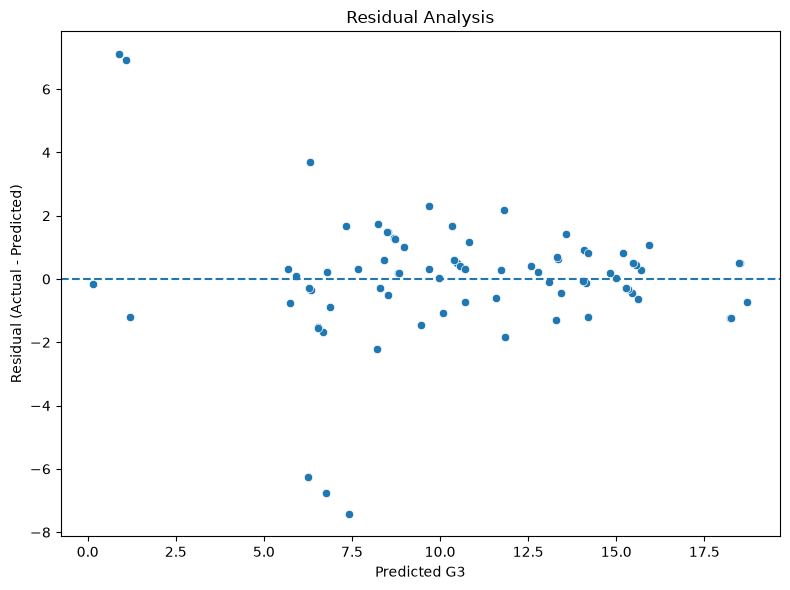

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=final_predictions, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted G3')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Analysis')
plt.tight_layout()
plt.show()

### Error Analysis Findings

The model performs better for students in the middle and upper grade ranges. Some of the largest prediction errors occur for extremely low-performing students, including cases where the actual final grade is 0 but the model predicts a substantially higher grade.

This indicates that the model has difficulty identifying certain extreme low-performance patterns.

# 18. Key Findings

### Finding 1 — Previous Academic Performance
`G2` is the strongest predictive feature, followed by `G1`.

### Finding 2 — Random Forest Performance
Random Forest achieved the strongest baseline results among the evaluated algorithms.

### Finding 3 — Importance of Previous Grades
Removing `G1` and `G2` reduced Random Forest R² from approximately 0.80 to 0.31.

### Finding 4 — Tuning Outcome
Hyperparameter tuning did not improve the baseline model. The tuned RMSE was 2.0196 compared with 2.0150 for the baseline.

### Finding 5 — Difficult Cases
The largest errors are concentrated among certain very low final-grade observations.

# 19. Limitations

1. The mathematics dataset contains only 395 students.
2. The data represents a specific educational context.
3. `G1` and `G2` provide strong predictive information but are not available for early-stage prediction.
4. Extreme low-grade observations remain difficult to predict.
5. Some potentially important real-world factors are not represented.
6. Feature importance should not be interpreted as causal influence.
7. Model performance should not automatically be generalized to other student populations.

# 20. Conclusion

This project demonstrates a complete supervised machine learning workflow for predicting student mathematics performance.

The final Random Forest model achieved:

| Metric | Final Result |
|---|---:|
| **MAE** | **1.2005** |
| **MSE** | **4.0601** |
| **RMSE** | **2.0150** |
| **R²** | **0.8020** |

The analysis shows that previous academic performance, especially `G2`, is the strongest predictive signal for final mathematics performance. At the same time, the error analysis demonstrates that overall metrics should be complemented with detailed examination of difficult and extreme cases.

Overall, the project provides an end-to-end example of data validation, exploratory analysis, preprocessing, supervised learning, model comparison, evaluation, tuning, interpretation, and reporting.

# 21. Project Artifacts

| Component | Description |
|---|---|
| `data/` | Raw and cleaned datasets |
| `src/` | Python implementation of the complete workflow |
| `visualizations/` | Final project visualizations |
| `models/` | Trained Random Forest model and metadata |
| `README.md` | Project documentation |
| `Week_6_Student_Performance_Final_Report.pdf` | Final project report |

---

**Week 6 Student Performance Prediction — End of Notebook**